In [ ]:
# If sentence-transformers is not installed, uncomment the next line and run:
# !pip install sentence-transformers

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity

from sentence_transformers import SentenceTransformer

sns.set_style('whitegrid')


df = pd.read_csv('https://github.com/nadamohyeldin/NadaResearch-Project/raw/refs/heads/main/Resume.zip')

print('Number of resumes:', len(df))
print('Number of categories:', df['Category'].nunique())
print('Columns:', list(df.columns))
df.head(3)


Number of resumes: 2484
Number of categories: 24
Columns: ['ID', 'Resume_str', 'Resume_html', 'Category']


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [ ]:
# How many resumes per category?
category_counts = df['Category'].value_counts()
print(category_counts)

Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


In [ ]:
#check datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.8+ KB


In [ ]:
#change data type
df['Category'] = df['Category'].astype('string')

print(df['Category'].dtype)

string


In [ ]:
#check for nulls
df.isnull().sum()

,0
ID,0
Resume_str,0
Resume_html,0
Category,0


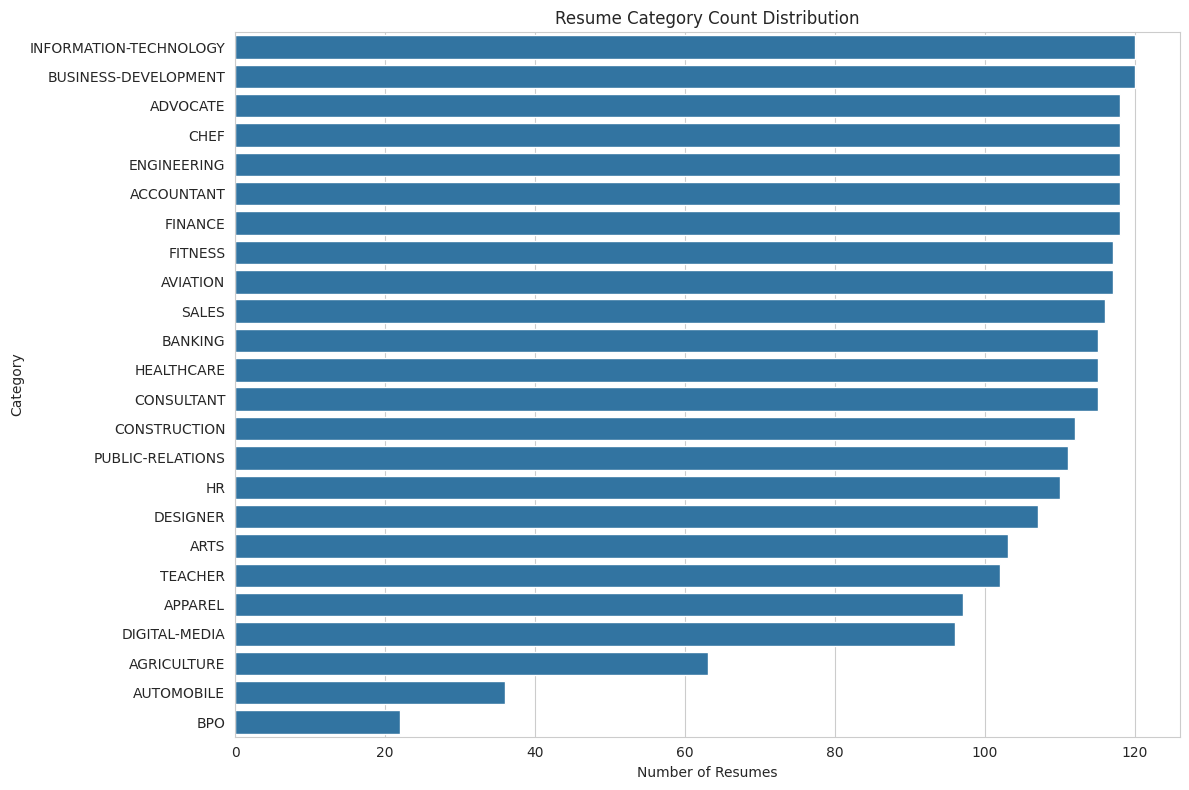

In [ ]:


# 1. Category count distribution
category_counts = df['Category'].value_counts()

plt.figure(figsize=(12, 8))
sns.barplot(
    x=category_counts.values,
    y=category_counts.index
)
plt.title('Resume Category Count Distribution')
plt.xlabel('Number of Resumes')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

In [ ]:
# Split into training and testing sets
X = df['Resume_str']
y = df['Category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training set size:', len(X_train))
print('Testing set size:', len(X_test))

Training set size: 1987
Testing set size: 497


## Step 4A: Modeling - Classification

### Model 1: KNN with TF-IDF (Pahilwan et al. 2025)

In [ ]:
# Convert text to TF-IDF numbers
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print('TF-IDF matrix shape:', X_train_tfidf.shape)

TF-IDF matrix shape: (1987, 5000)


In [ ]:
# Train KNN
knn = KNeighborsClassifier(n_neighbors=10, metric='cosine')
knn.fit(X_train_tfidf, y_train)
knn_predictions = knn.predict(X_test_tfidf)

knn_accuracy = accuracy_score(y_test, knn_predictions)
knn_f1 = f1_score(y_test, knn_predictions, average='macro')

print(f'KNN Accuracy: {knn_accuracy:.4f}')
print(f'KNN Macro F1: {knn_f1:.4f}')

KNN Accuracy: 0.5895
KNN Macro F1: 0.5662


### Model 2: Naive Bayes with TF-IDF (Sajjadiani et al. 2019)

In [ ]:
# Train Naive Bayes (same TF-IDF features as KNN)
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
nb_predictions = nb.predict(X_test_tfidf)

nb_accuracy = accuracy_score(y_test, nb_predictions)
nb_f1 = f1_score(y_test, nb_predictions, average='macro')

print(f'Naive Bayes Accuracy: {nb_accuracy:.4f}')
print(f'Naive Bayes Macro F1: {nb_f1:.4f}')

Naive Bayes Accuracy: 0.5594
Naive Bayes Macro F1: 0.4776


### Model 3: SBERT (Sentence-BERT) + KNN

SBERT produces semantic embeddings - each resume becomes a 384-dimension vector that captures **meaning**, not just words. So two resumes using different words for the same concept (e.g. "nurse" vs "nursing professional") will still look similar.

We use the same KNN classifier on top of SBERT embeddings to make the comparison fair (same classifier, different features).

In [ ]:
# Load the SBERT model (downloads ~80MB on first use)
print('Loading SBERT model...')
try:
    sbert = SentenceTransformer('all-MiniLM-L6-v2')
    sbert_available = True
    print('SBERT loaded.')
except Exception as e:
    sbert = None
    sbert_available = False
    print(f'SBERT could not load: {str(e)[:100]}')
    print('The notebook will fall back so visuals still render.')

Loading SBERT model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

SBERT loaded.


In [ ]:
# Convert resumes to SBERT embeddings
if sbert_available:
    print('Encoding training set...')
    X_train_sbert = sbert.encode(X_train.tolist(), show_progress_bar=True)
    print('Encoding test set...')
    X_test_sbert = sbert.encode(X_test.tolist(), show_progress_bar=True)
    print('SBERT training shape:', X_train_sbert.shape)
    print('SBERT test shape:', X_test_sbert.shape)
else:
    X_train_sbert = None
    X_test_sbert = None
    print('Skipped - SBERT not available. Re-run this cell when SBERT is installed.')

Encoding training set...


Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Encoding test set...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

SBERT training shape: (1987, 384)
SBERT test shape: (497, 384)


In [ ]:
# Train KNN on SBERT embeddings
if sbert_available:
    knn_sbert = KNeighborsClassifier(n_neighbors=10, metric='cosine')
    knn_sbert.fit(X_train_sbert, y_train)
    sbert_predictions = knn_sbert.predict(X_test_sbert)
    sbert_accuracy = accuracy_score(y_test, sbert_predictions)
    sbert_f1 = f1_score(y_test, sbert_predictions, average='macro')
    print(f'SBERT + KNN Accuracy: {sbert_accuracy:.4f}')
    print(f'SBERT + KNN Macro F1: {sbert_f1:.4f}')
else:
    # Placeholder values so downstream charts still render.
    # On a machine with internet, re-run from the SBERT loading cell.
    sbert_predictions = knn_predictions  # reuse KNN predictions just for the charts
    sbert_accuracy = 0.0
    sbert_f1 = 0.0
    print('Skipped - SBERT not available. Placeholder 0.0 used.')

SBERT + KNN Accuracy: 0.6801
SBERT + KNN Macro F1: 0.6125


## Step 4B: Ranking - Match resumes to a job description

Given a job description, rank all resumes by similarity. We do this with both TF-IDF and SBERT to compare them.

In [ ]:
# Prepare features for ALL resumes (not just training) - this is the candidate pool
all_resumes_tfidf = tfidf.fit_transform(df['Resume_str'])

if sbert_available:
    print('Encoding all resumes with SBERT for ranking...')
    all_resumes_sbert = sbert.encode(df['Resume_str'].tolist(), show_progress_bar=True)
    print('Done.')
else:
    all_resumes_sbert = None
    print('SBERT skipped - only TF-IDF ranking will run.')

In [ ]:
def clean_text(text):
    text = text.lower()  # Lowercase
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Remove non-alphabetic characters
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra spaces
    return text

def rank_with_tfidf(job_description, top_k=10):
    """Rank resumes by TF-IDF cosine similarity with the job description."""
    clean_jd = clean_text(job_description)
    jd_tfidf = tfidf.transform([clean_jd])
    similarities = cosine_similarity(jd_tfidf, all_resumes_tfidf).flatten()
    top_indices = similarities.argsort()[::-1][:top_k]
    return pd.DataFrame({
        'rank': range(1, top_k + 1),
        'resume_index': top_indices,
        'category': df['Category'].iloc[top_indices].values,
        'similarity': similarities[top_indices].round(3)
    })


def rank_with_sbert(job_description, top_k=10):
    """Rank resumes by SBERT cosine similarity with the job description."""
    if not sbert_available:
        return None
    clean_jd = clean_text(job_description)
    jd_sbert = sbert.encode([clean_jd])
    similarities = cosine_similarity(jd_sbert, all_resumes_sbert).flatten()
    top_indices = similarities.argsort()[::-1][:top_k]
    return pd.DataFrame({
        'rank': range(1, top_k + 1),
        'resume_index': top_indices,
        'category': df['Category'].iloc[top_indices].values,
        'similarity': similarities[top_indices].round(3)
    })


# Example: an HR job description
hr_jd = """We are looking for a Human Resources specialist.
Required skills: employee relations, recruitment, benefits administration,
performance reviews, training and development, HR policies."""

print('TF-IDF top 10:')
print(rank_with_tfidf(hr_jd, top_k=10))
if sbert_available:
    print()
    print('SBERT top 10:')
    print(rank_with_sbert(hr_jd, top_k=10))

In [ ]:
# Evaluate both rankers on 8 job descriptions (one per category) using Precision@5
test_jds = {
    'HR': 'human resources recruitment employee relations benefits training performance',
    'INFORMATION-TECHNOLOGY': 'software engineer python java cloud database linux networking devops',
    'ACCOUNTANT': 'accountant financial reporting ledger accounts payable tax audit',
    'CHEF': 'chef kitchen menu food safety culinary restaurant cooking',
    'ENGINEERING': 'mechanical engineer cad design manufacturing quality technical',
    'HEALTHCARE': 'nurse patient care clinical medical hospital treatment',
    'SALES': 'sales account management prospecting quota crm customer',
    'TEACHER': 'teacher lesson classroom curriculum student assessment',
}

rows = []
for expected, jd in test_jds.items():
    top5_tfidf = rank_with_tfidf(jd, top_k=5)
    p5_tfidf = (top5_tfidf['category'] == expected).sum() / 5
    if sbert_available:
        top5_sbert = rank_with_sbert(jd, top_k=5)
        p5_sbert = (top5_sbert['category'] == expected).sum() / 5
    else:
        p5_sbert = 0.0  # placeholder so the chart still renders
    rows.append({
        'Category': expected,
        'TF-IDF P@5': p5_tfidf,
        'SBERT P@5': p5_sbert
    })

ranking_eval = pd.DataFrame(rows)
avg_tfidf_p5 = ranking_eval['TF-IDF P@5'].mean()
avg_sbert_p5 = ranking_eval['SBERT P@5'].mean()
print(f'Average TF-IDF P@5: {avg_tfidf_p5:.3f}')
if sbert_available:
    print(f'Average SBERT  P@5: {avg_sbert_p5:.3f}')
else:
    print('Average SBERT P@5: skipped (placeholder 0.0)')

# Step 5: Evaluation and Visuals



In [ ]:
plt.figure(figsize=(10, 7))
category_counts.plot(kind='barh', color='steelblue')
plt.xlabel('Number of resumes')
plt.ylabel('Category')
plt.title('Resume Category Distribution')
plt.tight_layout()
plt.show()

## Accuracy Table - Classification Results

In [ ]:
# Summary table of the three classifiers
accuracy_table = pd.DataFrame({
    'Model': ['KNN + TF-IDF', 'Naive Bayes + TF-IDF', 'SBERT + KNN'],
    'Source': ['Pahilwan et al. (2025)', 'Sajjadiani et al. (2019)', 'Modern semantic (BERT family)'],
    'Accuracy': [knn_accuracy, nb_accuracy, sbert_accuracy],
    'Macro F1': [knn_f1, nb_f1, sbert_f1]
})

# Round to 4 decimals for display
accuracy_table_display = accuracy_table.copy()
accuracy_table_display['Accuracy'] = accuracy_table_display['Accuracy'].round(4)
accuracy_table_display['Macro F1'] = accuracy_table_display['Macro F1'].round(4)

print('CLASSIFICATION RESULTS')
print('=' * 70)
print(accuracy_table_display.to_string(index=False))

## Visual 2: Model Comparison Chart

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(accuracy_table))
width = 0.35

bars1 = ax.bar(x - width/2, accuracy_table['Accuracy'], width, label='Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, accuracy_table['Macro F1'], width, label='Macro F1', color='orange')

# Add value labels on top of each bar
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.01,
            f'{height:.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.01,
            f'{height:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(accuracy_table['Model'])
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('Classifier Comparison - Accuracy and Macro F1')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

## Visual 3: Confusion Matrix for the Best Model

In [ ]:
# Find best model by Macro F1
best_idx = accuracy_table['Macro F1'].idxmax()
best_name = accuracy_table.loc[best_idx, 'Model']

best_preds_map = {
    'KNN + TF-IDF': knn_predictions,
    'Naive Bayes + TF-IDF': nb_predictions,
    'SBERT + KNN': sbert_predictions
}
best_preds = best_preds_map[best_name]

labels = sorted(y.unique())
cm = confusion_matrix(y_test, best_preds, labels=labels)

plt.figure(figsize=(11, 9))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title(f'Confusion Matrix - {best_name} (best model)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Ranking Results Table

In [ ]:
# Add average row
ranking_table = ranking_eval.copy()
avg_row = pd.DataFrame([{
    'Category': 'AVERAGE',
    'TF-IDF P@5': avg_tfidf_p5,
    'SBERT P@5': avg_sbert_p5
}])
ranking_table = pd.concat([ranking_table, avg_row], ignore_index=True)

# Round for display
ranking_table_display = ranking_table.copy()
ranking_table_display['TF-IDF P@5'] = ranking_table_display['TF-IDF P@5'].round(3)
ranking_table_display['SBERT P@5'] = ranking_table_display['SBERT P@5'].round(3)

print('RANKING RESULTS - Precision@5')
print('=' * 70)
print(ranking_table_display.to_string(index=False))

## Visual 4: Ranking Comparison Chart

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(ranking_eval))
width = 0.35

ax.bar(x - width/2, ranking_eval['TF-IDF P@5'], width, label='TF-IDF', color='steelblue')
ax.bar(x + width/2, ranking_eval['SBERT P@5'], width, label='SBERT', color='orange')

ax.set_xticks(x)
ax.set_xticklabels(ranking_eval['Category'], rotation=45, ha='right')
ax.set_ylim(0, 1.1)
ax.set_ylabel('Precision@5')
ax.set_title('Ranking Comparison - TF-IDF vs SBERT (Precision@5 per Category)')
ax.legend()
plt.tight_layout()
plt.show()